# 🤖 Tema 5 — Modelado y evaluación de modelos

## *Estrategia del Dato: Machine Learning y Deep Learning*

### Dataset: 🏋️ GymPro (continuación del Tema 4)

---

En el **Tema 4** preparamos y limpiamos los datos del gimnasio GymPro: tratamos nulos, outliers, codificamos categóricas, escalamos…

**Ahora damos el siguiente paso**: usar esos datos limpios para **entrenar modelos de Machine Learning** y aprender a:

| 🔢 | Concepto | Herramienta |
|---|---|---|
| 1 | **Elegir el modelo adecuado** | Mapa de algoritmos de scikit-learn |
| 2 | **Dividir los datos** | `train_test_split` (train / val / test) |
| 3 | **Evaluar la generalización** | Validación cruzada (`KFold`, `cross_val_score`) |
| 4 | **Medir el rendimiento** | Métricas de clasificación y regresión |
| 5 | **Detectar sobreajuste** | Comparar train vs test |
| 6 | **Optimizar hiperparámetros** | `GridSearchCV` y `RandomizedSearchCV` |
| 7 | **Comparar modelos** | Selección del modelo final |

### 🎯 Los dos casos que veremos en este notebook

Para cubrir **todas las métricas y familias de modelos** del temario, vamos a plantear dos problemas a la vez sobre el mismo dataset:

1. 🟦 **Caso A — Clasificación binaria:** ¿es este socio un **cliente premium**? → predecir si el `Plan` es Premium o VIP a partir del resto de variables.
2. 🟩 **Caso B — Regresión:** ¿cuántas **calorías quemará por sesión** un socio nuevo? → predecir `Calorias_quemadas` a partir del resto de variables.

> ⚠️ **Antes de empezar:** asegúrate de tener el archivo `gimnasio_gympro.csv` subido al entorno de Colab (panel izquierdo → 📁 → subir archivo).


---

## 1. ♻️ Recordatorio: cargamos los datos y reaplicamos el pipeline del Tema 4

Antes de modelar tenemos que **partir de datos limpios**. Vamos a aplicar de un tirón el pipeline de preprocesamiento que vimos en el Tema 4 (duplicados, nulos, outliers, categóricas, escalado).

> 💡 *No te detengas aquí: si no te suena algo, repasa el Tema 4. La explicación detallada está allí.*


In [1]:
# Importaciones básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (10, 5)

# Importaciones de scikit-learn (las iremos usando a lo largo del notebook)
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_score, cross_validate,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Modelos de CLASIFICACIÓN
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Modelos de REGRESIÓN
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Métricas
from sklearn.metrics import (
    # Clasificación
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    # Regresión
    mean_absolute_error, mean_squared_error, r2_score
)

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [2]:
# Carga del CSV (el mismo que usamos en el Tema 4)
df = pd.read_csv("gimnasio_gympro.csv")
print("Forma inicial:", df.shape)
df.head()

Forma inicial: (308, 15)


,ID_Socio,Nombre,Genero,Edad,Altura_cm,Peso_kg,Ciudad,Plan,Cuota_mensual_EUR,Antiguedad_meses,Dias_por_semana,Minutos_por_sesion,Calorias_quemadas,Satisfaccion,Fecha_inscripcion
0,1001,María Molina,F,41.0,NaN,86.4,Madrid,Estándar,29.99,103,7,51.0,465.0,7.0,2025-08-18
1,1002,Daniel González,femenino,33.0,164.4,NaN,Granada,Premium,49.99,68,1,42.0,300.0,3.0,2024-07-18
2,1003,Claudia López,F,43.0,177.5,88.0,Madrid,Básico,49.99,115,7,57.0,518.0,6.0,2021-04-25
3,1004,Lucía García,F,53.0,176.1,95.3,Barcelona,Básico,39.99,1,3,94.0,949.0,NaN,2025-02-26
4,1005,Daniel Navarro,M,32.0,169.8,81.2,Madrid,Básico,29.99,92,6,NaN,212.0,9.0,2020-07-04


In [3]:
# Pipeline de limpieza condensado del Tema 4
# (consulta el Tema 4 para la explicación detallada de cada paso)

# 1) Duplicados
df = df.drop_duplicates().reset_index(drop=True)

# 2) Limpieza de categóricas
df["Genero"] = (df["Genero"].str.strip().str.lower()
                .map({"m": "M", "f": "F", "masculino": "M", "femenino": "F"}))
df["Plan"]   = df["Plan"].str.strip().str.capitalize().replace({"Vip": "VIP"})
df["Ciudad"] = df["Ciudad"].str.strip().str.capitalize()

# 3) Imputación de nulos
for col in ["Edad", "Minutos_por_sesion", "Calorias_quemadas"]:
    df[col] = df[col].fillna(df[col].median())
for col in ["Altura_cm", "Peso_kg"]:
    df[col] = df[col].fillna(df[col].mean())
for col in ["Satisfaccion", "Ciudad"]:
    df[col] = df[col].fillna(df[col].mode()[0])

# 4) Outliers (sustitución por mediana)
def tratar_outliers_iqr(serie):
    Q1, Q3 = serie.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mediana = serie.median()
    return serie.where((serie >= lim_inf) & (serie <= lim_sup), mediana)

for col in ["Edad", "Altura_cm", "Peso_kg", "Minutos_por_sesion"]:
    df[col] = tratar_outliers_iqr(df[col])

print(f"✅ Pipeline aplicado. Forma final: {df.shape}")
print(f"   NaN restantes: {df.isnull().sum().sum()}")
df.head()

✅ Pipeline aplicado. Forma final: (301, 15)
   NaN restantes: 0


,ID_Socio,Nombre,Genero,Edad,Altura_cm,Peso_kg,Ciudad,Plan,Cuota_mensual_EUR,Antiguedad_meses,Dias_por_semana,Minutos_por_sesion,Calorias_quemadas,Satisfaccion,Fecha_inscripcion
0,1001,María Molina,F,41.0,169.653261,86.4000,Madrid,Estándar,29.99,103,7,51.0,465.0,7.0,2025-08-18
1,1002,Daniel González,F,33.0,164.400000,76.8025,Granada,Premium,49.99,68,1,42.0,300.0,3.0,2024-07-18
2,1003,Claudia López,F,43.0,177.500000,88.0000,Madrid,Básico,49.99,115,7,57.0,518.0,6.0,2021-04-25
3,1004,Lucía García,F,53.0,176.100000,95.3000,Barcelona,Básico,39.99,1,3,94.0,949.0,7.0,2025-02-26
4,1005,Daniel Navarro,M,32.0,169.800000,81.2000,Madrid,Básico,29.99,92,6,62.0,212.0,9.0,2020-07-04


---

## 2. 🗺️ Selección del modelo

Antes de tocar código, hay que **decidir qué tipo de problema** queremos resolver. Esto determina qué algoritmos podemos usar.

### 🔎 Los 3 tipos de problemas en ML supervisado y no supervisado

| Tipo | ¿Qué predice? | Ejemplos | Algoritmos típicos |
|---|---|---|---|
| **Regresión** | Valor **continuo** | Precio de una casa, calorías quemadas | LinearRegression, Ridge, Lasso, RandomForestRegressor |
| **Clasificación** | **Categoría** | Spam/No spam, Premium/No premium | LogisticRegression, KNN, DecisionTree, RandomForest, SVM |
| **Clustering** | **Grupos naturales** | Segmentos de clientes | KMeans, DBSCAN, GMM |

### 🧭 El mapa de algoritmos de scikit-learn

Scikit-learn ofrece [este diagrama de flujo](https://scikit-learn.org/stable/tutorial/machine_learning_map/) que, a partir del **tamaño del dataset**, **tipo de variable a predecir** y **algunas propiedades**, te sugiere un algoritmo de partida.

> 💡 *Es solo una guía, no un dogma. Lo habitual es probar varios algoritmos y comparar.*

### 🎯 Nuestros dos casos

| Caso | Tipo | Variable a predecir |
|---|---|---|
| 🟦 **A** | Clasificación binaria | `Cliente_Premium` (1 si Plan ∈ {Premium, VIP}, 0 si no) |
| 🟩 **B** | Regresión | `Calorias_quemadas` |


In [4]:
# Creamos la variable objetivo del CASO A: clasificación binaria
df["Cliente_Premium"] = df["Plan"].isin(["Premium", "VIP"]).astype(int)

# Distribución de la nueva variable
print("Distribución de Cliente_Premium:")
print(df["Cliente_Premium"].value_counts())
print(f"\n% premium: {df['Cliente_Premium'].mean()*100:.1f}%")

Distribución de Cliente_Premium:
Cliente_Premium
0    234
1     67
Name: count, dtype: int64

% premium: 22.3%


In [5]:
# Codificamos las categóricas restantes para que los modelos las puedan usar
# Genero: M=1, F=0
df["Genero_M"] = (df["Genero"] == "M").astype(int)

# Ciudad: One-Hot encoding
df = pd.get_dummies(df, columns=["Ciudad"], prefix="Ciudad", drop_first=True)

# Eliminamos columnas que ya no necesitamos para modelar
df_modelado = df.drop(columns=["ID_Socio", "Nombre", "Genero", "Plan",
                                "Fecha_inscripcion"])

print("Columnas finales para el modelado:")
print(df_modelado.columns.tolist())
df_modelado.head()

Columnas finales para el modelado:
['Edad', 'Altura_cm', 'Peso_kg', 'Cuota_mensual_EUR', 'Antiguedad_meses', 'Dias_por_semana', 'Minutos_por_sesion', 'Calorias_quemadas', 'Satisfaccion', 'Cliente_Premium', 'Genero_M', 'Ciudad_Bilbao', 'Ciudad_Granada', 'Ciudad_Madrid', 'Ciudad_Málaga', 'Ciudad_Sevilla', 'Ciudad_Valencia', 'Ciudad_Zaragoza']


,Edad,Altura_cm,Peso_kg,Cuota_mensual_EUR,Antiguedad_meses,Dias_por_semana,Minutos_por_sesion,Calorias_quemadas,Satisfaccion,Cliente_Premium,Genero_M,Ciudad_Bilbao,Ciudad_Granada,Ciudad_Madrid,Ciudad_Málaga,Ciudad_Sevilla,Ciudad_Valencia,Ciudad_Zaragoza
0,41.0,169.653261,86.4000,29.99,103,7,51.0,465.0,7.0,0,0,False,False,True,False,False,False,False
1,33.0,164.400000,76.8025,49.99,68,1,42.0,300.0,3.0,1,0,False,True,False,False,False,False,False
2,43.0,177.500000,88.0000,49.99,115,7,57.0,518.0,6.0,0,0,False,False,True,False,False,False,False
3,53.0,176.100000,95.3000,39.99,1,3,94.0,949.0,7.0,0,0,False,False,False,False,False,False,False
4,32.0,169.800000,81.2000,29.99,92,6,62.0,212.0,9.0,0,1,False,False,True,False,False,False,False


---

# 🟦 CASO A — Clasificación: ¿Es un cliente premium?

Vamos a entrenar varios modelos para predecir la columna `Cliente_Premium` (1 = sí, 0 = no) a partir del resto de variables.


## 3.A.1. Separar X (features) e y (target)

Por convención en ML:
- **`X`** → matriz de **características** (variables explicativas, *features*).
- **`y`** → vector con la **variable objetivo** (lo que queremos predecir).


In [6]:
# Eliminamos la columna 'Cuota_mensual_EUR' porque está MUY correlacionada
# con el Plan (sería casi hacer trampa: el modelo lo adivinaría enseguida)
X = df_modelado.drop(columns=["Cliente_Premium", "Cuota_mensual_EUR",
                               "Calorias_quemadas"])
y = df_modelado["Cliente_Premium"]

print("X (features):", X.shape)
print("y (target):  ", y.shape)
print("\nPrimeras filas de X:")
X.head()

X (features): (301, 15)
y (target):   (301,)

Primeras filas de X:


,Edad,Altura_cm,Peso_kg,Antiguedad_meses,Dias_por_semana,Minutos_por_sesion,Satisfaccion,Genero_M,Ciudad_Bilbao,Ciudad_Granada,Ciudad_Madrid,Ciudad_Málaga,Ciudad_Sevilla,Ciudad_Valencia,Ciudad_Zaragoza
0,41.0,169.653261,86.4000,103,7,51.0,7.0,0,False,False,True,False,False,False,False
1,33.0,164.400000,76.8025,68,1,42.0,3.0,0,False,True,False,False,False,False,False
2,43.0,177.500000,88.0000,115,7,57.0,6.0,0,False,False,True,False,False,False,False
3,53.0,176.100000,95.3000,1,3,94.0,7.0,0,False,False,False,False,False,False,False
4,32.0,169.800000,81.2000,92,6,62.0,9.0,1,False,False,True,False,False,False,False


## 3.A.2. División en train / test (y opcionalmente validación)

Tenemos que separar los datos para **evaluar el modelo en datos que NO ha visto durante el entrenamiento**. Si no, no sabríamos si está aprendiendo de verdad o solo memorizando.

### 🧱 Las particiones clásicas

| Partición | Para qué sirve | % típico |
|---|---|---|
| **Train** | Entrenar el modelo | 60-80% |
| **Validation** | Ajustar hiperparámetros | 10-20% |
| **Test** | Evaluación final, una sola vez | 10-20% |

> 💡 **Si vamos a usar validación cruzada** (que es lo más habitual), basta con dividir en **train + test**. La validación se hará "dentro" del train con K-folds.

### ⚖️ Parámetros importantes de `train_test_split`
- `test_size=0.2` → 20% para test.
- `random_state=42` → reproducibilidad (siempre el mismo split).
- `stratify=y` → mantiene la **proporción de clases** en cada partición (¡fundamental si hay desbalanceo!).


In [7]:
# División 80% train / 20% test, estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y     # mantiene la proporción de premium / no premium
)

print(f"Train: {X_train.shape} — premium ratio: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape} — premium ratio: {y_test.mean():.2%}")

Train: (240, 15) — premium ratio: 22.08%
Test:  (61, 15) — premium ratio: 22.95%


### 📏 Escalado de variables numéricas

Algunos modelos (Regresión Logística, KNN, SVM) son **sensibles a la escala**. Otros (árboles, Random Forest) NO lo son.

⚠️ **Regla de oro**: el `StandardScaler` se **`fit`-ea solo con el train** y luego se aplica (`transform`) al test. Si lo ajustáramos con todo el dataset estaríamos "filtrando" información del test al modelo (*data leakage*).


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform → SOLO con train
X_test_scaled  = scaler.transform(X_test)        # transform → reutiliza la media/std del train

print("Media de X_train escalado (debería ser ~0):", round(X_train_scaled.mean(), 4))
print("Std de X_train escalado (debería ser ~1):  ", round(X_train_scaled.std(), 4))

Media de X_train escalado (debería ser ~0): -0.0
Std de X_train escalado (debería ser ~1):   1.0


## 3.A.3. Entrenar un primer modelo: Regresión Logística

Empezamos con el modelo **más simple e interpretable** para clasificación binaria: la **Regresión Logística**.

> 🤔 ¿Por qué "regresión" si es para clasificar? Porque internamente predice la **probabilidad** (un valor continuo entre 0 y 1) de pertenecer a la clase positiva. Luego, con un umbral (típicamente 0.5), decide la clase.

### 🧪 El "Hello world" de scikit-learn

Todos los modelos de scikit-learn tienen la **misma API**:

```python
modelo = NombreDelModelo(parámetros…)   # 1) instanciar
modelo.fit(X_train, y_train)            # 2) entrenar
preds  = modelo.predict(X_test)         # 3) predecir
```

Esto es **enormemente potente**: si quieres cambiar de modelo, solo cambias la primera línea.


In [9]:
# 1) Instanciamos
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# 2) Entrenamos con los datos de train (escalados)
log_reg.fit(X_train_scaled, y_train)

# 3) Predecimos sobre train y test
y_pred_train = log_reg.predict(X_train_scaled)
y_pred_test  = log_reg.predict(X_test_scaled)

print("✅ Regresión Logística entrenada")
print(f"\nPrecisión en TRAIN: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Precisión en TEST:  {accuracy_score(y_test,  y_pred_test):.4f}")

✅ Regresión Logística entrenada

Precisión en TRAIN: 0.7792
Precisión en TEST:  0.7705


> 🚨 **Comparar siempre train vs test es OBLIGATORIO.** Si la precisión en train es muy superior a la de test, hay **sobreajuste**.


## 3.A.4. Métricas de clasificación

`accuracy` (% de aciertos) **no es la única métrica** ni siempre la mejor. Especialmente cuando hay **clases desbalanceadas** (más muestras de una clase que de otra).

### 📊 Las 4 métricas básicas y la matriz de confusión

| Métrica | Fórmula | ¿Qué mide? | ¿Cuándo es crítica? |
|---|---|---|---|
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ | % de aciertos totales | Clases equilibradas |
| **Precision** | $\frac{TP}{TP+FP}$ | De los predichos positivos, ¿cuántos lo eran? | Cuando los **falsos positivos** son caros |
| **Recall** (Sensibilidad) | $\frac{TP}{TP+FN}$ | De los positivos reales, ¿cuántos detectamos? | Cuando los **falsos negativos** son caros |
| **F1-Score** | media armónica de Precision y Recall | Balance entre las dos anteriores | Clases desbalanceadas |

**TP** = Verdaderos Positivos, **TN** = Verdaderos Negativos, **FP** = Falsos Positivos, **FN** = Falsos Negativos.


In [10]:
# Calculamos las cuatro métricas básicas sobre el TEST
print("== MÉTRICAS DEL MODELO BASE (Regresión Logística) en TEST ==")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_test):.4f}")

== MÉTRICAS DEL MODELO BASE (Regresión Logística) en TEST ==
  Accuracy:  0.7705
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000


/sessions/zen-beautiful-volta/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [11]:
# Reporte completo de clasificación (incluye soporte por clase)
print(classification_report(y_test, y_pred_test,
                            target_names=["No Premium", "Premium"]))

              precision    recall  f1-score   support

  No Premium       0.77      1.00      0.87        47
     Premium       0.00      0.00      0.00        14

    accuracy                           0.77        61
   macro avg       0.39      0.50      0.44        61
weighted avg       0.59      0.77      0.67        61



/sessions/zen-beautiful-volta/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/sessions/zen-beautiful-volta/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/sessions/zen-beautiful-volta/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

### 🟦 La matriz de confusión

Visualiza dónde acierta y dónde falla el modelo. Es una de las herramientas **más útiles** para diagnosticar errores.


Matriz de confusión:
 [[47  0]
 [14  0]]


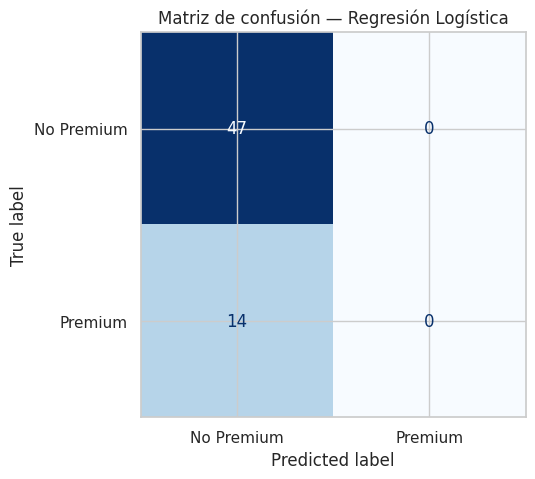

In [12]:
cm = confusion_matrix(y_test, y_pred_test)
print("Matriz de confusión:\n", cm)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["No Premium", "Premium"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Matriz de confusión — Regresión Logística")
plt.show()

## 3.A.5. Validación cruzada

Hacer un único `train_test_split` tiene un problema: **el resultado depende de qué muestras hayan caído en cada partición**. Si tenemos mala suerte, podemos tener una estimación sesgada.

### 🔁 K-Fold Cross-Validation

La validación cruzada divide los datos en **K particiones (folds)** y entrena el modelo K veces, usando cada vez un fold distinto como test. La métrica final es el promedio.

> 💡 **Ventajas**: estimación más robusta del rendimiento, especialmente útil en datasets pequeños como el nuestro.

`cross_val_score` hace todo esto en una línea:


In [13]:
# 5-Fold Cross-Validation con stratified (mantiene la proporción de clases)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_cv = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    X_train_scaled, y_train,
    cv=cv,
    scoring="f1"     # usamos f1 porque las clases están algo desbalanceadas
)

print("Scores F1 en cada fold:", np.round(scores_cv, 4))
print(f"\nMedia F1: {scores_cv.mean():.4f}")
print(f"Std  F1:  {scores_cv.std():.4f}")

Scores F1 en cada fold: [0.1667 0.     0.     0.     0.    ]

Media F1: 0.0333
Std  F1:  0.0667


> 📈 *Si la **desviación estándar** entre folds es alta, el modelo es **inestable** (su rendimiento depende mucho de los datos concretos). Si es baja, es un modelo **robusto**.*


## 3.A.6. Comparación de varios modelos

No nos quedamos solo con la Regresión Logística. Vamos a probar varios algoritmos y comparar.

> 🧠 **Recuerda:** la API de scikit-learn es la misma para todos. Cambiamos solo el nombre del modelo.


In [14]:
# Diccionario de modelos a probar
modelos_clf = {
    "Regresión Logística": LogisticRegression(random_state=42, max_iter=1000),
    "KNN (k=5)":           KNeighborsClassifier(n_neighbors=5),
    "Árbol de decisión":   DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42, n_estimators=100),
    "SVM (RBF)":           SVC(random_state=42, kernel="rbf")
}

resultados = []
for nombre, modelo in modelos_clf.items():
    # Validación cruzada con F1
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring="f1")
    # Entrenamos en todo el train y evaluamos en test
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    resultados.append({
        "Modelo": nombre,
        "F1 (CV media)": scores.mean(),
        "F1 (CV std)":   scores.std(),
        "Accuracy test": accuracy_score(y_test, y_pred),
        "F1 test":       f1_score(y_test, y_pred),
        "Precision test": precision_score(y_test, y_pred),
        "Recall test":    recall_score(y_test, y_pred),
    })

df_resultados = pd.DataFrame(resultados).sort_values("F1 test", ascending=False)
df_resultados.round(4)

/sessions/zen-beautiful-volta/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/sessions/zen-beautiful-volta/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/sessions/zen-beautiful-volta/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Modelo,F1 (CV media),F1 (CV std),Accuracy test,F1 test,Precision test,Recall test
2,Árbol de decisión,0.2212,0.0766,0.6393,0.1538,0.1667,0.1429
0,Regresión Logística,0.0333,0.0667,0.7705,0.0000,0.0000,0.0000
1,KNN (k=5),0.0552,0.0677,0.7705,0.0000,0.0000,0.0000
3,Random Forest,0.0333,0.0667,0.7377,0.0000,0.0000,0.0000
4,SVM (RBF),0.0000,0.0000,0.7705,0.0000,0.0000,0.0000


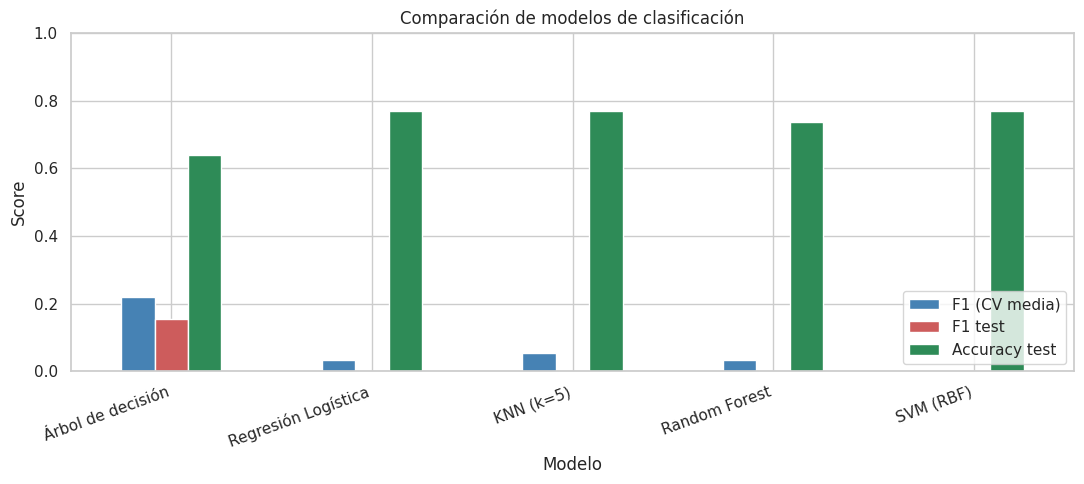

In [15]:
# Visualizamos la comparación
fig, ax = plt.subplots(figsize=(11, 5))
df_resultados.set_index("Modelo")[["F1 (CV media)", "F1 test", "Accuracy test"]].plot(
    kind="bar", ax=ax, color=["steelblue", "indianred", "seagreen"]
)
ax.set_title("Comparación de modelos de clasificación")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 3.A.7. Optimización de hiperparámetros con `GridSearchCV`

### 🎛️ Parámetros vs Hiperparámetros

| | **Parámetros** | **Hiperparámetros** |
|---|---|---|
| ¿Quién los fija? | El modelo (aprende solo) | El desarrollador (antes de entrenar) |
| Ejemplo en LogReg | Los coeficientes $\beta_i$ | `C`, `penalty`, `solver` |
| Ejemplo en RF | Las ramas del árbol | `n_estimators`, `max_depth` |

### 🔍 GridSearchCV
Prueba **todas las combinaciones** de un diccionario de hiperparámetros y se queda con la mejor según una métrica + validación cruzada.

> ⚠️ El nº de combinaciones crece **multiplicativamente**: 3 valores en 4 parámetros → 81 combinaciones × 5 folds = 405 entrenamientos. ¡Cuidado con el tamaño del grid!


In [16]:
# Optimización del Random Forest (el ganador inicial)
param_grid_rf = {
    "n_estimators":     [50, 100, 200],
    "max_depth":        [None, 5, 10, 20],
    "min_samples_split":[2, 5, 10],
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=cv,
    scoring="f1",
    n_jobs=-1,     # usa todos los núcleos disponibles
    verbose=1
)

grid_rf.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros:", grid_rf.best_params_)
print(f"Mejor F1 (CV):           {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits


Mejores hiperparámetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Mejor F1 (CV):           0.0364


In [17]:
# Evaluamos el modelo optimizado sobre el TEST
mejor_rf = grid_rf.best_estimator_
y_pred_opt = mejor_rf.predict(X_test_scaled)

print("== RANDOM FOREST OPTIMIZADO en TEST ==")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_opt):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_opt):.4f}")

== RANDOM FOREST OPTIMIZADO en TEST ==
  Accuracy:  0.7541
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000


In [18]:
# Exploramos cv_results_ para ver el detalle de la búsqueda
cv_results = pd.DataFrame(grid_rf.cv_results_)
top5 = cv_results.sort_values("rank_test_score").head(5)
top5[["params", "mean_test_score", "std_test_score", "rank_test_score"]]

,params,mean_test_score,std_test_score,rank_test_score
35,"{'max_depth': 20, 'min_samples_split': 10, 'n_...",0.036364,0.072727,1
23,"{'max_depth': 10, 'min_samples_split': 5, 'n_e...",0.036364,0.072727,1
26,"{'max_depth': 10, 'min_samples_split': 10, 'n_...",0.036364,0.072727,1
11,"{'max_depth': 5, 'min_samples_split': 2, 'n_es...",0.036364,0.072727,1
10,"{'max_depth': 5, 'min_samples_split': 2, 'n_es...",0.036364,0.072727,1


## 3.A.8. Optimización con `RandomizedSearchCV`

`GridSearchCV` puede explotar si el grid es grande. `RandomizedSearchCV` **muestrea aleatoriamente** N combinaciones del espacio de hiperparámetros, lo que es muchísimo más rápido y suele dar resultados muy parecidos.

> 💡 *En la práctica: usa Randomized para una **búsqueda amplia** y luego Grid para **refinar** alrededor de los mejores valores.*


In [19]:
from scipy.stats import randint

# Espacio de búsqueda más amplio (con distribuciones para muestrear)
param_dist_rf = {
    "n_estimators":     randint(50, 300),
    "max_depth":        [None, 5, 10, 15, 20, 30],
    "min_samples_split":randint(2, 20),
    "min_samples_leaf": randint(1, 10),
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=20,           # solo 20 combinaciones aleatorias
    cv=cv,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
)
random_search.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros (Randomized):", random_search.best_params_)
print(f"Mejor F1 (CV): {random_search.best_score_:.4f}")

Mejores hiperparámetros (Randomized): {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 99}
Mejor F1 (CV): 0.0364


## 3.A.9. Curva ROC y AUC

Cuando el modelo predice **probabilidades**, podemos analizar su rendimiento a **distintos umbrales de decisión** con la **curva ROC**.

- **AUC (Area Under the Curve)** va de 0 a 1. 0.5 = aleatorio, 1.0 = perfecto.


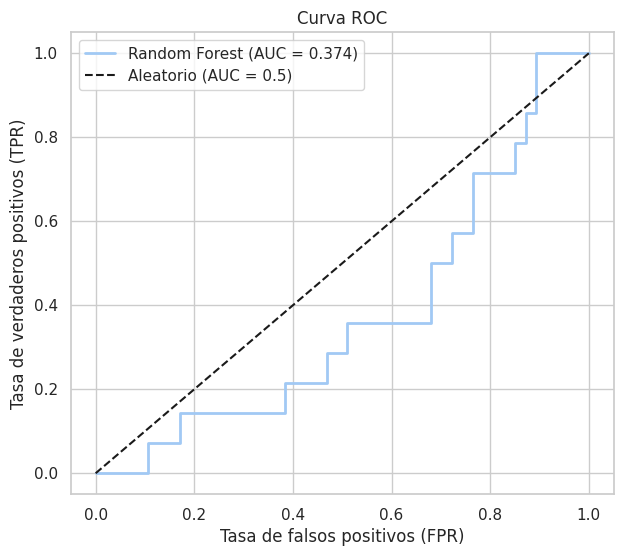

In [20]:
# Probabilidades del modelo optimizado
y_proba = mejor_rf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Aleatorio (AUC = 0.5)")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.show()

---

# 🟩 CASO B — Regresión: predecir las calorías quemadas

Cambiamos de problema. Ahora queremos predecir un **valor continuo**: `Calorias_quemadas`. Es decir, estamos ante un **problema de regresión**.

Mismos pasos que antes, pero con:
- Modelos de regresión (`LinearRegression`, `Ridge`, `Lasso`, `RandomForestRegressor`…).
- Métricas de regresión (MAE, MSE, RMSE, R², R² ajustado).


## 3.B.1. Preparación de X e y


In [21]:
# Variables explicativas
Xr = df_modelado.drop(columns=["Calorias_quemadas", "Cliente_Premium"])
yr = df_modelado["Calorias_quemadas"]

print("Xr:", Xr.shape, "  yr:", yr.shape)

# División train / test
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=42
)

# Escalado (importante para regresión lineal, Ridge, Lasso)
scaler_r = StandardScaler()
Xr_train_sc = scaler_r.fit_transform(Xr_train)
Xr_test_sc  = scaler_r.transform(Xr_test)

print("Train:", Xr_train.shape, "  Test:", Xr_test.shape)

Xr: (301, 16)   yr: (301,)
Train: (240, 16)   Test: (61, 16)


## 3.B.2. Modelo base: Regresión Lineal

La **regresión lineal** ajusta una línea (o hiperplano) que minimiza la suma de errores al cuadrado entre las predicciones y los valores reales.

$$ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n $$


In [22]:
lin_reg = LinearRegression()
lin_reg.fit(Xr_train_sc, yr_train)

yr_pred_train = lin_reg.predict(Xr_train_sc)
yr_pred_test  = lin_reg.predict(Xr_test_sc)

print("✅ Regresión Lineal entrenada")
print(f"R² en train: {r2_score(yr_train, yr_pred_train):.4f}")
print(f"R² en test:  {r2_score(yr_test,  yr_pred_test):.4f}")

✅ Regresión Lineal entrenada
R² en train: 0.5707
R² en test:  0.2970


## 3.B.3. Métricas de regresión

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum |y - \hat{y}|$ | Error medio absoluto. **Misma unidad** que la variable. Robusto a outliers. |
| **MSE** | $\frac{1}{n}\sum (y - \hat{y})^2$ | Penaliza más los errores grandes. **Unidades²**. |
| **RMSE** | $\sqrt{MSE}$ | Mismo significado que MSE pero en la **misma unidad** de la variable. |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | % de varianza explicada. 1 = perfecto, 0 = como predecir la media, <0 = peor que la media. |
| **R² ajustado** | corrige R² por nº de variables | Útil para comparar modelos con distinto nº de features. |


In [23]:
def metricas_regresion(y_real, y_pred, n_features=None):
    mae  = mean_absolute_error(y_real, y_pred)
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_real, y_pred)
    out = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R²": r2}
    if n_features is not None:
        n = len(y_real)
        k = n_features
        r2_adj = 1 - (1 - r2) * (n - 1) / (n - k - 1)
        out["R² ajustado"] = r2_adj
    return out

print("== MÉTRICAS — Regresión Lineal en TEST ==")
for k, v in metricas_regresion(yr_test, yr_pred_test, n_features=Xr.shape[1]).items():
    print(f"  {k}: {v:.4f}")

== MÉTRICAS — Regresión Lineal en TEST ==
  MAE: 116.1540
  MSE: 47464.6448
  RMSE: 217.8638
  R²: 0.2970
  R² ajustado: 0.0413


### 📈 Visualización: ¿Predicciones vs realidad?
Un buen modelo de regresión debería tener los puntos alineados sobre la diagonal `y = x`.


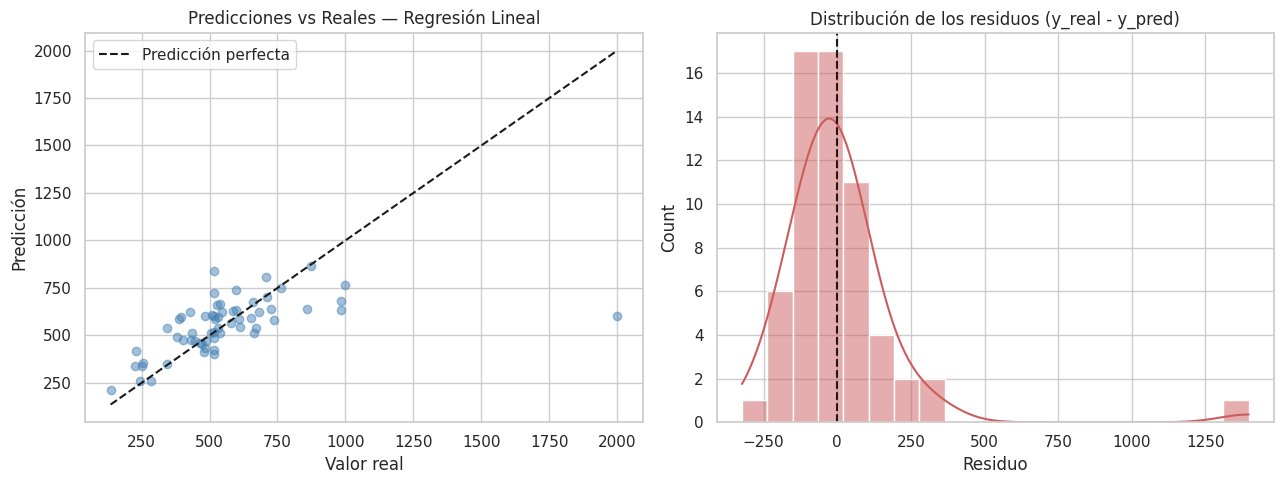

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicciones vs reales
axes[0].scatter(yr_test, yr_pred_test, alpha=0.5, color="steelblue")
axes[0].plot([yr_test.min(), yr_test.max()],
             [yr_test.min(), yr_test.max()], "k--", label="Predicción perfecta")
axes[0].set_xlabel("Valor real")
axes[0].set_ylabel("Predicción")
axes[0].set_title("Predicciones vs Reales — Regresión Lineal")
axes[0].legend()

# Distribución de los residuos
residuos = yr_test - yr_pred_test
sns.histplot(residuos, kde=True, ax=axes[1], color="indianred", bins=20)
axes[1].axvline(0, color="k", linestyle="--")
axes[1].set_title("Distribución de los residuos (y_real - y_pred)")
axes[1].set_xlabel("Residuo")

plt.tight_layout()
plt.show()

## 3.B.4. Regularización: Ridge y Lasso

Ya conocemos la regresión lineal estándar. Pero existen **versiones regularizadas** que ayudan a evitar el sobreajuste y a hacer **selección de variables** automáticamente.

| Modelo | Regularización | Efecto |
|---|---|---|
| **Ridge** | L2 ($\sum \beta_i^2$) | Reduce los coeficientes pero **no los hace 0** |
| **Lasso** | L1 ($\sum |\beta_i|$) | Puede llevar coeficientes a **0 exactamente** (feature selection) |

El hiperparámetro **`alpha`** controla la fuerza de la regularización (más alto = más regularización).


In [25]:
# Comparamos varios modelos de regresión
modelos_reg = {
    "Regresión Lineal":  LinearRegression(),
    "Ridge (α=1)":       Ridge(alpha=1.0, random_state=42),
    "Ridge (α=10)":      Ridge(alpha=10.0, random_state=42),
    "Lasso (α=0.1)":     Lasso(alpha=0.1, random_state=42, max_iter=5000),
    "Árbol de Regresión":DecisionTreeRegressor(random_state=42, max_depth=5),
    "Random Forest":     RandomForestRegressor(random_state=42, n_estimators=100),
}

resultados_r = []
for nombre, modelo in modelos_reg.items():
    modelo.fit(Xr_train_sc, yr_train)
    pred_train = modelo.predict(Xr_train_sc)
    pred_test  = modelo.predict(Xr_test_sc)

    resultados_r.append({
        "Modelo":   nombre,
        "MAE test": mean_absolute_error(yr_test, pred_test),
        "RMSE test":np.sqrt(mean_squared_error(yr_test, pred_test)),
        "R² train": r2_score(yr_train, pred_train),
        "R² test":  r2_score(yr_test,  pred_test),
    })

df_reg = pd.DataFrame(resultados_r).sort_values("R² test", ascending=False)
df_reg.round(4)

,Modelo,MAE test,RMSE test,R² train,R² test
0,Regresión Lineal,116.1540,217.8638,0.5707,0.2970
1,Ridge (α=1),116.1751,217.8998,0.5707,0.2967
3,Lasso (α=0.1),116.0932,217.9094,0.5707,0.2967
2,Ridge (α=10),116.3507,218.2459,0.5696,0.2945
5,Random Forest,127.5054,222.1778,0.9282,0.2689
4,Árbol de Regresión,133.7664,244.0364,0.7486,0.1179


> 🚨 **Detectar sobreajuste:** si el R² en train es muy superior al R² en test, hay sobreajuste. Por ejemplo, los árboles de decisión sin podar suelen dar **R² = 1.0 en train** y mucho menos en test.


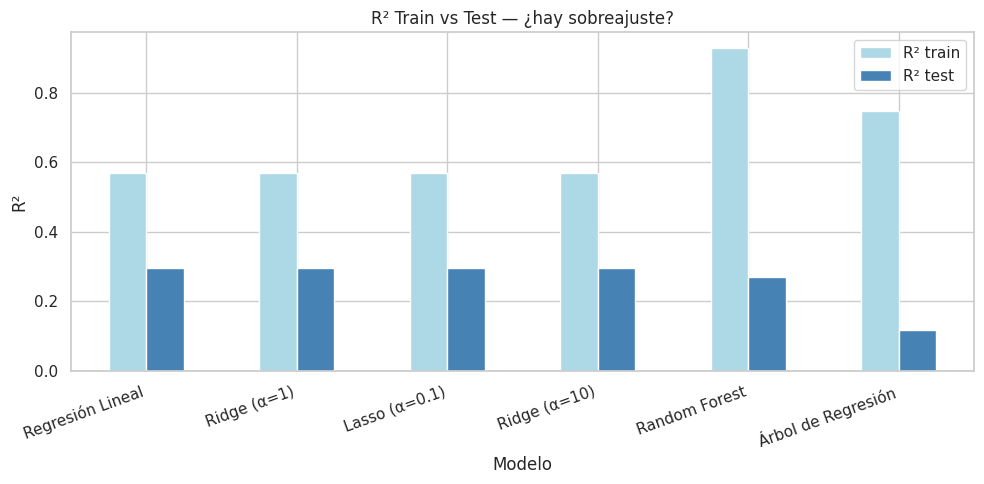

In [26]:
# Visualización del R² train vs test (detección de sobreajuste)
fig, ax = plt.subplots(figsize=(10, 5))
df_reg.set_index("Modelo")[["R² train", "R² test"]].plot(
    kind="bar", ax=ax, color=["lightblue", "steelblue"]
)
ax.axhline(0, color="k", linewidth=0.5)
ax.set_title("R² Train vs Test — ¿hay sobreajuste?")
ax.set_ylabel("R²")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 3.B.5. GridSearchCV para regresión

Optimizamos un **RandomForestRegressor** igual que hicimos para clasificación.


In [27]:
param_grid_rfr = {
    "n_estimators":     [50, 100, 200],
    "max_depth":        [None, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4],
}

# Para regresión usamos scoring='r2' o 'neg_mean_squared_error'
grid_rfr = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rfr,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid_rfr.fit(Xr_train_sc, yr_train)

print("Mejores hiperparámetros:", grid_rfr.best_params_)
print(f"Mejor R² (CV):           {grid_rfr.best_score_:.4f}")

# Evaluación final sobre test
mejor_rfr = grid_rfr.best_estimator_
yr_pred_opt = mejor_rfr.predict(Xr_test_sc)
print(f"\n== RANDOM FOREST REGRESSOR OPTIMIZADO en TEST ==")
for k, v in metricas_regresion(yr_test, yr_pred_opt, n_features=Xr.shape[1]).items():
    print(f"  {k}: {v:.4f}")

Mejores hiperparámetros: {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 100}
Mejor R² (CV):           0.4561

== RANDOM FOREST REGRESSOR OPTIMIZADO en TEST ==
  MAE: 123.0076
  MSE: 48722.1294
  RMSE: 220.7309
  R²: 0.2784
  R² ajustado: 0.0159


## 3.B.6. Importancia de variables (feature importance)

Los modelos basados en árboles te dan un atributo `feature_importances_` que cuantifica **cuánto pesa cada variable** en las decisiones del modelo. Es una forma muy intuitiva de **interpretar** el modelo.


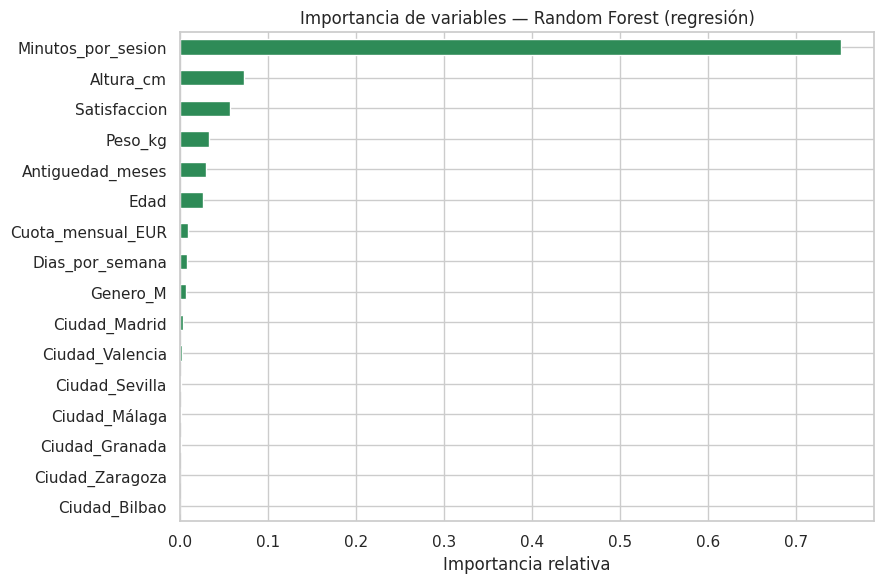

In [28]:
importancias = pd.Series(mejor_rfr.feature_importances_, index=Xr.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importancias.plot(kind="barh", color="seagreen")
plt.title("Importancia de variables — Random Forest (regresión)")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

> 💡 Las variables con mayor importancia son las que más **información aportan** al modelo. Si una variable tiene importancia ~0, se podría eliminar sin penalización (feature selection).


---

## 🏁 Resumen final del Tema 5

| ✅ | Concepto | Herramienta |
|---|---|---|
| ✅ | Selección de modelo | Mapa de scikit-learn |
| ✅ | División train/test | `train_test_split` (con `stratify`) |
| ✅ | Validación cruzada | `KFold`, `StratifiedKFold`, `cross_val_score` |
| ✅ | Clasificación binaria | `LogisticRegression`, `KNN`, `DecisionTree`, `RandomForest`, `SVM` |
| ✅ | Regresión | `LinearRegression`, `Ridge`, `Lasso`, `RandomForestRegressor` |
| ✅ | Métricas clasificación | accuracy, precision, recall, F1, matriz confusión, ROC/AUC |
| ✅ | Métricas regresión | MAE, MSE, RMSE, R², R² ajustado |
| ✅ | Optimización exhaustiva | `GridSearchCV` |
| ✅ | Optimización aleatoria | `RandomizedSearchCV` |
| ✅ | Detección de sobreajuste | comparar train vs test |
| ✅ | Regularización | Ridge (L2), Lasso (L1) |
| ✅ | Interpretabilidad | `feature_importances_` |

### 📚 Para profundizar

- [Mapa de algoritmos de scikit-learn](https://scikit-learn.org/stable/tutorial/machine_learning_map/)
- [Cross-validation user guide](https://scikit-learn.org/stable/modules/cross_validation.html)
- [Feature selection](https://scikit-learn.org/stable/modules/feature_selection.html)
- [Tipos de regularización](https://towardsdatascience.com/types-of-regularization-in-machine-learning-eb5ce5f9bf50)
- [How to identify overfitting](https://machinelearningmastery.com/overfitting-machine-learning-models/)

---

### 🚀 Próximo paso

Llevar todo este conocimiento a la **Actividad 1: Palladium**, donde tendréis que aplicar este mismo flujo (preprocesamiento + modelado + evaluación + optimización) sobre un nuevo dataset… **y justificar cada decisión que toméis**.

✏️ **Profesor: Miguel Ángel Navarro Arenas**
🎓 **UNIR — Estrategia del Dato: Machine Learning y Deep Learning**
